# Contract Simulation and Benchmark Comparison

This notebook builds the daily load-reduction scenario, solves the deterministic and robust contract models, and compares customer utilities and reductions across schemes.

Most implementation details now live in `mechanism_design/` so this notebook stays focused on experiment inputs, solver calls, and figures.


In [1]:
from pathlib import Path

import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

from mechanism_design.contract_models import (
    compute_contract_utilities,
    compute_discriminatory_utilities,
    solve_naive_from_perfect,
    solve_perfect_information_contract,
    solve_proposed_contract,
    solve_robust_contract_convex,
)
from mechanism_design.data import DATASET_DIR_NAME, build_load_scenario
from mechanism_design.plots import (
    DEFAULT_FIGURE_DPI,
    plot_ic_curves,
    plot_load_reduction,
    plot_type_bars,
    plot_type_lines,
)
from mechanism_design.transport import build_cost_matrix


## Experiment Inputs

Change the distribution `f`, the robust radii, or the demand-requirement range here. The data path is relative to this repository instead of the hard-coded desktop path used in the original notebook.


In [2]:
M = 80
T = 24
N = 5

FIGURE_DIR = Path("figures")
FIGURE_DPI = DEFAULT_FIGURE_DPI  # 600 dpi PDF output for publication figures.
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

#f = np.array([0.10, 0.15, 0.20, 0.25, 0.3], dtype=float)
f = np.array([0.30, 0.25, 0.20, 0.15, 0.1], dtype=float)


robust_radii = [0.1, 0.8]

scenario = build_load_scenario(
    M=M,
    T=T,
    N=N,
    folder=Path(DATASET_DIR_NAME),
    price_scale=2.0,
    dreq_low=100.0,
    dreq_high=200.0,
    seed=42,
)

c_mat = build_cost_matrix(np.arange(N))

print(f"Loaded {len(scenario.files)} CSV files from: {scenario.folder}")
print("Files:", [path.name for path in scenario.files])
print("d_n shape:", scenario.d_n.shape)
print("Feasibility report:", scenario.feasibility_report)
print("Krt:", np.round(scenario.Krt, 4))
print("Ks:", round(scenario.Ks, 4))
print("Dreq:", np.round(scenario.Dreq, 4))
print("Figures will be saved to:", FIGURE_DIR.resolve())


Loaded 5 CSV files from: Dataset on Hourly Load Profiles for 8 Facilities (8760 hours)
Files: ['Industrial-1-shift Fabricated Metals.csv', 'Industrial-2-shift Fabricated Metals.csv', 'Industrial-Food Processing.csv', 'Industrial-Pharmaceutical.csv', 'Industrial-Plastic Manufacturer.csv']
d_n shape: (5, 24)
Feasibility report: {'sum_Krt': 2528.4, 'Ks': 2571.13, 'gap': 42.73000000000002, 'daily_cap_covers_hourly_caps': True}
Krt: [ 50.    62.    50.    62.    50.    62.    50.    62.   154.12 176.56
 216.   227.64 163.24 175.08 214.88 226.88  79.    69.    57.    69.
  57.    69.    57.    69.  ]
Ks: 2571.13
Dreq: [177.3956 143.8878 185.8598 169.7368 109.4177 197.5622 176.114  178.6064
 112.8114 145.0386 137.0798 192.6765 164.3865 182.2762 144.3414 122.7239
 155.4585 106.3817 182.7631 163.1664 175.8088 135.4526 197.0698 189.3121]
Figures will be saved to: C:\Users\User\Desktop\simulations-v3\figures


## Deterministic Benchmarks

The proposed contract includes monotonicity and aggregate balance constraints. The perfect-information benchmark preserves the original notebook behavior, where the aggregate `Dreq` balance was not imposed unless `include_balance=True` is passed.


In [3]:
proposed = solve_proposed_contract(
    M=scenario.M,
    T=scenario.T,
    N=scenario.N,
    Krt=scenario.Krt,
    Ks=scenario.Ks,
    Dreq=scenario.Dreq,
    pi=scenario.pi,
    alpha=scenario.alpha,
    beta=scenario.beta,
    f=f,
    verbose=1,
)

perfect = solve_perfect_information_contract(
    M=scenario.M,
    T=scenario.T,
    N=scenario.N,
    Krt=scenario.Krt,
    Ks=scenario.Ks,
    Dreq=scenario.Dreq,
    pi=scenario.pi,
    alpha=scenario.alpha,
    beta=scenario.beta,
    f=f,
    verbose=1,
)

naive = solve_naive_from_perfect(
    M=scenario.M,
    pi=scenario.pi,
    alpha=scenario.alpha,
    beta=scenario.beta,
    perfect_D=perfect.D,
)

D_opt_proposed = proposed.D
D_opt_perfect = perfect.D
D_opt_naive = naive.D

print("Proposed objective:", proposed.objective)
print("Perfect-information objective:", perfect.objective)
print("Naive objective:", naive.objective)


`xtol` termination condition is satisfied.
Number of iterations: 90, function evaluations: 127, CG iterations: 818, optimality: 4.11e-09, constraint violation: 0.00e+00, execution time: 0.68 s.
`xtol` termination condition is satisfied.
Number of iterations: 85, function evaluations: 131, CG iterations: 199, optimality: 1.92e-07, constraint violation: 0.00e+00, execution time: 0.33 s.
Proposed objective: 14896.410945336185
Perfect-information objective: 17546.145854145863
Naive objective: 13650.857142857143


## Robust Proposed Contract

This is the convex CVXPY reformulation from the original notebook. It solves one robust contract for each Wasserstein radius in `robust_radii`.


In [4]:
robust_solutions = {}
for radius in robust_radii:
    sol = solve_robust_contract_convex(
        M=scenario.M,
        T=scenario.T,
        N=scenario.N,
        Krt=scenario.Krt,
        Ks=scenario.Ks,
        Dreq=scenario.Dreq,
        pi=scenario.pi,
        alpha=scenario.alpha,
        beta=scenario.beta,
        fhat=f,
        r=radius,
        c_mat=c_mat,
        verbose=True,
    )
    robust_solutions[radius] = sol
    print(f"r={radius}: status={sol.status}, solver={sol.solver}, objective={sol.objective}")


(CVXPY) Jul 31 06:51:49 PM: Your problem has 270 variables, 990 constraints, and 0 parameters.
(CVXPY) Jul 31 06:51:49 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 31 06:51:49 PM: DCP verification time: 0.0785 seconds.
(CVXPY) Jul 31 06:51:49 PM: Expression tree has 12 nodes.
(CVXPY) Jul 31 06:51:49 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 31 06:51:49 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 31 06:51:49 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jul 31 06:51:49 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) Jul 31 06:51:49 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> EliminateZeroSized -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Jul 31 06:51:49 PM: Applying reduction FlipObjective
(CVXPY) Jul 31 06:51:49 PM: Applying reduction Dcp2Cone


                                     CVXPY                                     
                                     v1.9.2                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jul 31 06:51:49 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jul 31 06:51:50 PM: Applying reduction EliminateZeroSized
(CVXPY) Jul 31 06:51:50 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Jul 31 06:51:50 PM: Applying reduction CLARABEL
(CVXPY) Jul 31 06:51:50 PM: Finished problem compilation (took 8.081e-01 seconds).
(CVXPY) Jul 31 06:51:50 PM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 630
  constraints   = 2095
  nnz(P)        = 0
  nnz(A)        = 7126
  cones (total) = 361
    : Nonnegative = 1,  numel = 1015
    : SecondOrder = 360,  numel = (3,3,3,3,...,3)

settings:
  linear algebra: direct / qdldl, precision: 64 bit (1 thread)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  static reg : on, ϵ1 = 1.0e-8, ϵ2 = 4.9e-32


(CVXPY) Jul 31 06:51:50 PM: Problem status: optimal
(CVXPY) Jul 31 06:51:50 PM: Optimal value: 1.475e+04
(CVXPY) Jul 31 06:51:50 PM: Compilation took 8.081e-01 seconds
(CVXPY) Jul 31 06:51:50 PM: Solver (including time spent in interface) took 2.865e-02 seconds
(CVXPY) Jul 31 06:51:50 PM: Your problem has 270 variables, 990 constraints, and 0 parameters.


...

-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jul 31 06:51:51 PM: Applying reduction EliminateZeroSized
(CVXPY) Jul 31 06:51:51 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Jul 31 06:51:51 PM: Applying reduction CLARABEL
(CVXPY) Jul 31 06:51:51 PM: Finished problem compilation (took 7.824e-01 seconds).
(CVXPY) Jul 31 06:51:51 PM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 630
  constraints   = 2095
  nnz(P)        = 0
  nnz(A)        = 7126
  cones (total) = 361
    : Nonnegative = 1,  numel = 1015
    : SecondOrder = 360,  numel = (3,3,3,3,...,3)

settings:
  linear algebra: direct / qdldl, precision: 64 bit (1 thread)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  static reg : on, ϵ1 = 1.0e-8, ϵ2 = 4.9e-32


(CVXPY) Jul 31 06:51:51 PM: Problem status: optimal
(CVXPY) Jul 31 06:51:51 PM: Optimal value: 1.416e+04
(CVXPY) Jul 31 06:51:51 PM: Compilation took 7.824e-01 seconds
(CVXPY) Jul 31 06:51:51 PM: Solver (including time spent in interface) took 3.052e-02 seconds


  0  -1.0813e+06  -1.8995e+06  7.57e-01  1.19e-01  1.37e-03  1.00e+00  4.84e+03   ------   
  1  -8.7852e+05  -1.2536e+06  4.27e-01  6.67e-02  7.74e-04  1.77e+03  1.99e+03  9.16e-01  
  2  -7.7538e+05  -1.1911e+06  5.36e-01  8.04e-02  9.71e-04  2.39e+03  1.84e+03  2.51e-01  
  3  -3.9055e+05  -6.7561e+05  7.30e-01  9.46e-02  1.31e-03  2.41e+03  1.12e+03  8.05e-01  
  4  -2.1010e+05  -3.4718e+05  6.52e-01  7.51e-02  1.15e-03  1.24e+03  5.78e+02  5.86e-01  
  5  -7.3088e+04  -1.2415e+05  6.99e-01  6.21e-02  1.20e-03  5.13e+02  2.21e+02  7.29e-01  
  6  -7.8295e+04  -1.2960e+05  6.55e-01  6.26e-02  1.13e-03  5.30e+02  2.04e+02  3.03e-01  
  7  -3.7522e+04  -5.3686e+04  4.31e-01  4.74e-02  7.31e-04  1.34e+02  6.85e+01  7.87e-01  
  8  -2.3579e+04  -2.7265e+04  1.56e-01  2.18e-02  2.71e-04  2.06e+01  1.92e+01  7.42e-01  
  9  -1.9301e+04  -2.1674e+04  1.23e-01  1.67e-02  2.12e-04  1.47e+01  1.54e+01  4.36e-01  
 10  -1.6144e+04  -1.7009e+04  5.36e-02  7.20e-03  9.26e-05  4.93e+00  6.86e+00 

## IC/IR Diagnostics

For every menu of contracts, we recover the per-type reward rates, then check truthful reporting and individual rationality per hour.


In [5]:
proposed_check = compute_contract_utilities(proposed.D, scenario.alpha, scenario.beta)
robust_checks = {
    radius: compute_contract_utilities(sol.D, scenario.alpha, scenario.beta)
    for radius, sol in robust_solutions.items()
    if sol.D is not None
}
perfect_utility = compute_discriminatory_utilities(perfect.D, scenario.alpha, scenario.beta)

rows = [
    {
        "scenario": "proposed",
        "objective": proposed.objective,
        "IR ok": proposed_check.ir_ok,
        "IC ok": proposed_check.ic_ok,
        "min IR": proposed_check.min_ir,
        "min IC gap": proposed_check.min_ic_gap,
    },
]
for radius, sol in robust_solutions.items():
    check = robust_checks.get(radius)
    rows.append(
        {
            "scenario": f"robust r={radius}",
            "objective": sol.objective,
            "IR ok": None if check is None else check.ir_ok,
            "IC ok": None if check is None else check.ic_ok,
            "min IR": None if check is None else check.min_ir,
            "min IC gap": None if check is None else check.min_ic_gap,
        }
    )

if pd is not None:
    display(pd.DataFrame(rows))
else:
    for row in rows:
        print(row)


,scenario,objective,IR ok,IC ok,min IR,min IC gap
0,proposed,14896.410945,True,True,-6.661338e-16,-2.886580e-15
1,robust r=0.1,14754.891446,True,True,-4.440892e-16,-3.996803e-15
2,robust r=0.8,14163.615853,True,True,-4.440892e-16,-3.552714e-15


## Utility and Load-Reduction Plots


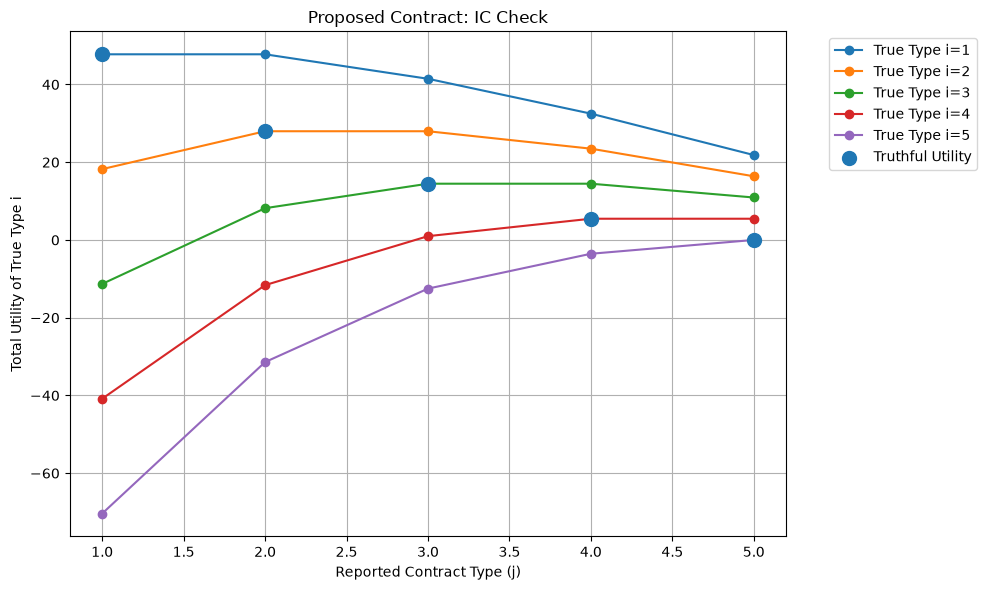

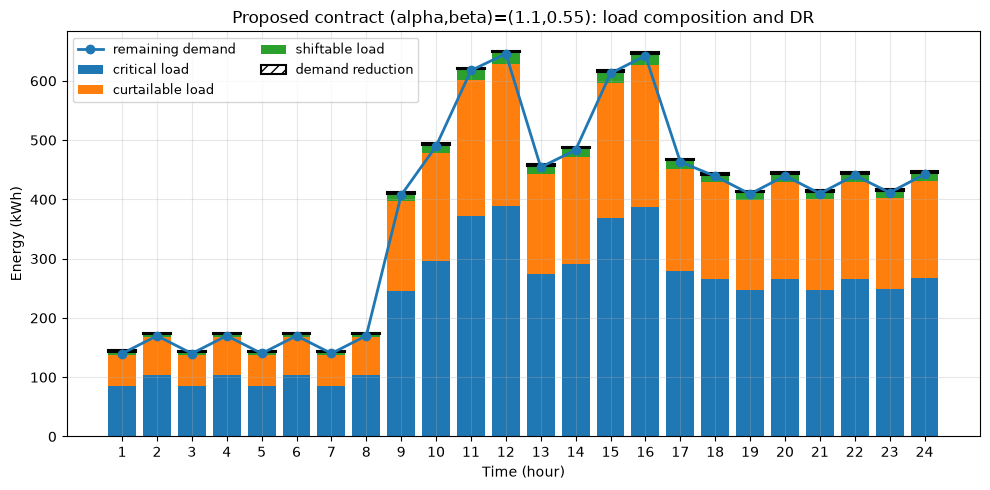

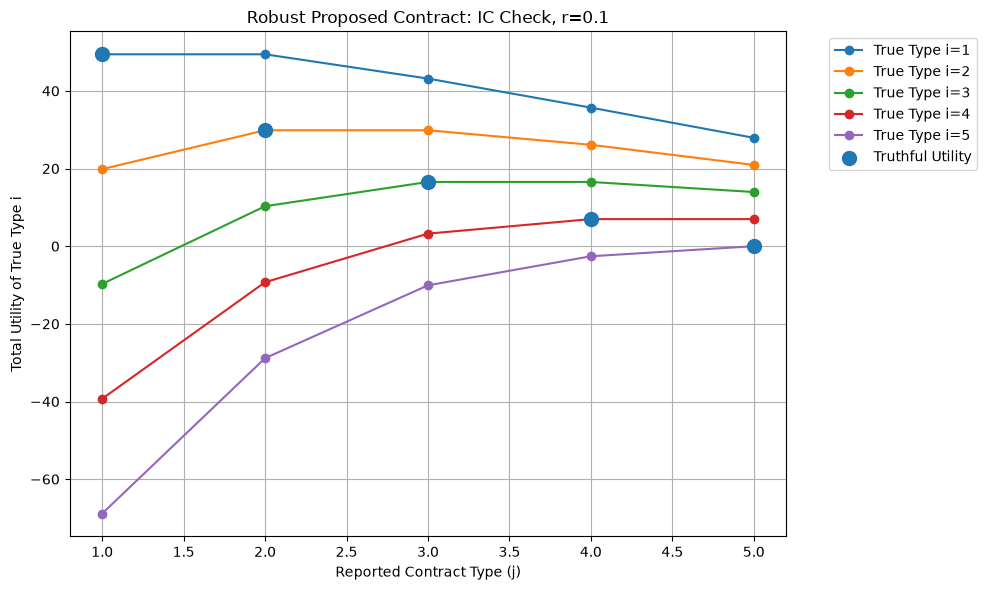

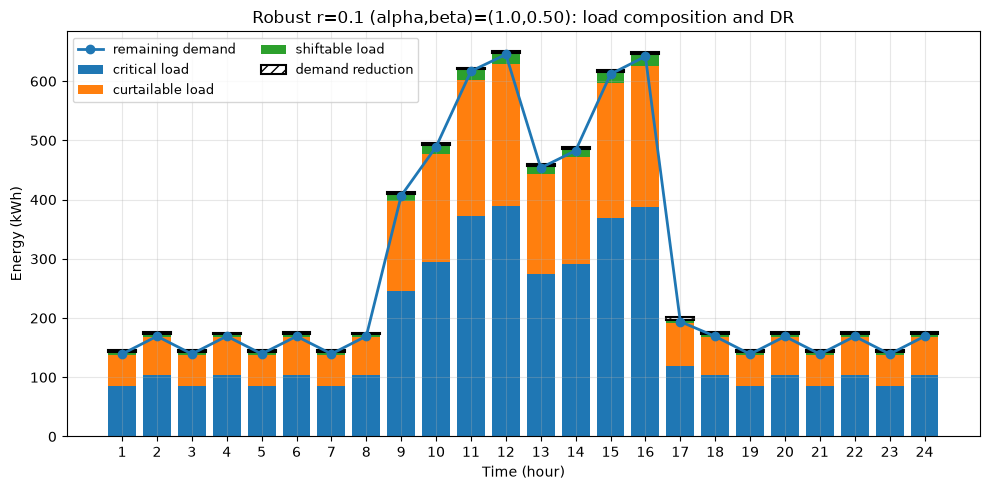

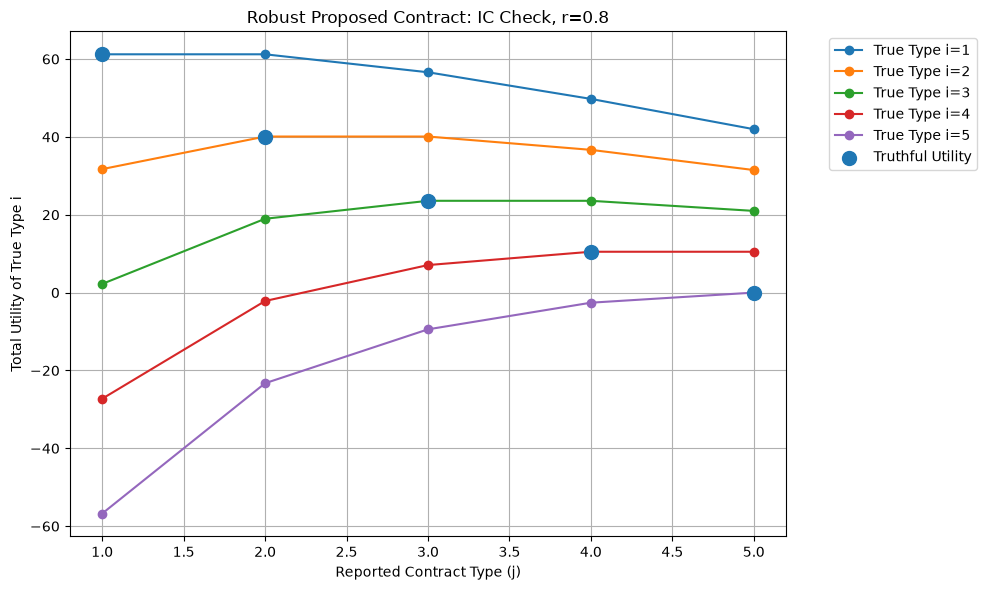

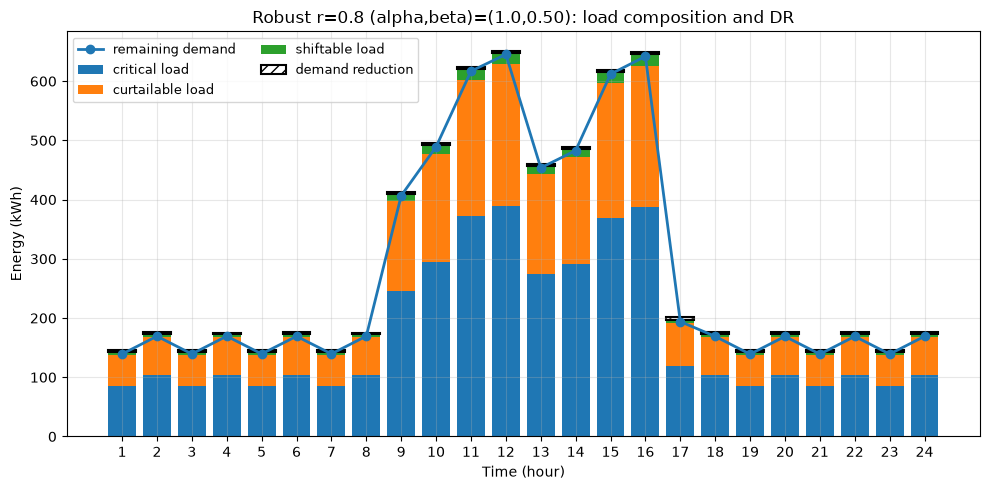

In [6]:
plot_ic_curves(
    proposed_check,
    title="Proposed Contract: IC Check",
    save_path=FIGURE_DIR / "proposed_ic.pdf",
    dpi=FIGURE_DPI,
)
plot_load_reduction(
    scenario,
    proposed.D,
    selected_type=1,
    title_prefix="Proposed contract",
    save_path=FIGURE_DIR / "proposed_load_reduction_type_2.pdf",
    dpi=FIGURE_DPI,
)

for radius, check in robust_checks.items():
    radius_label = str(radius).replace(".", "p")
    plot_ic_curves(
        check,
        title=f"Robust Proposed Contract: IC Check, r={radius}",
        save_path=FIGURE_DIR / f"robust_r_{radius_label}_ic.pdf",
        dpi=FIGURE_DPI,
    )
    plot_load_reduction(
        scenario,
        robust_solutions[radius].D,
        selected_type=0,
        title_prefix=f"Robust r={radius}",
        save_path=FIGURE_DIR / f"robust_r_{radius_label}_load_reduction_type_1.pdf",
        dpi=FIGURE_DPI,
    )


## Scenario Comparison

The utility comparison uses truthful utility for menu-based contracts, same-type utility for the perfect-information benchmark, and the realized utility of the naive contract.


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'CU Demand Reduction in Different Scenarios'}, xlabel='CU type', ylabel='CU demand reduction'>)

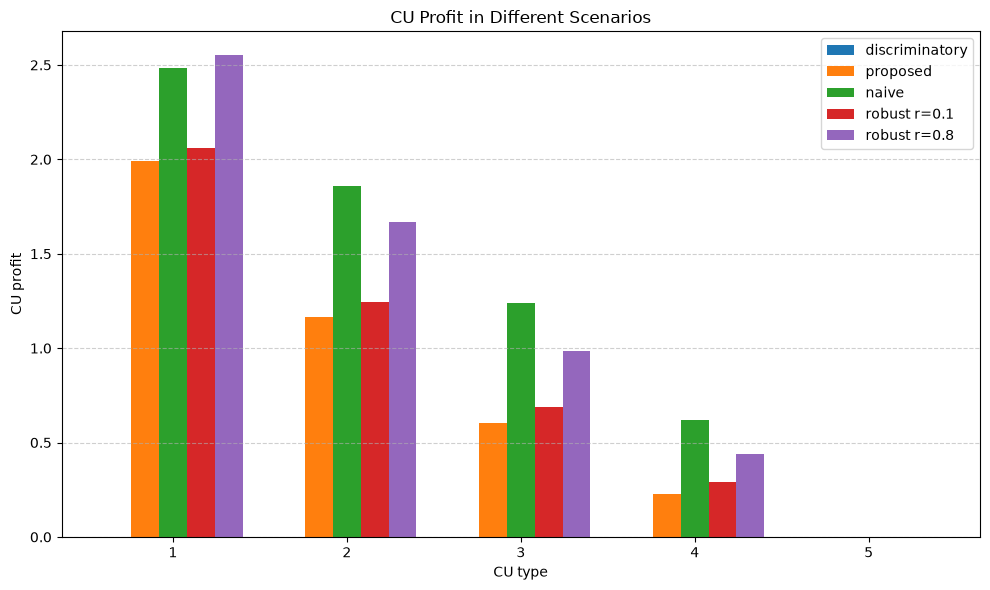

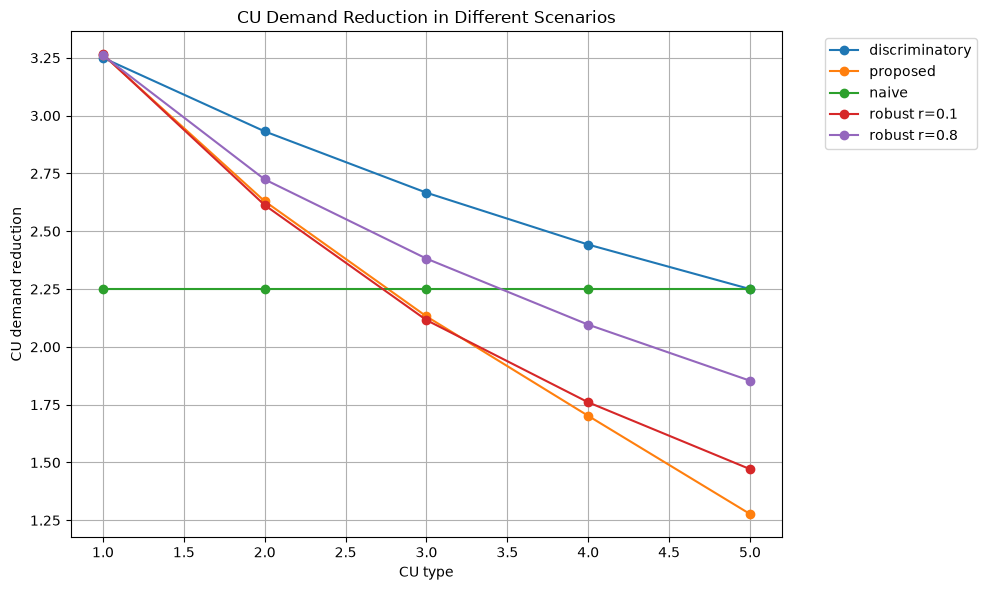

In [7]:
T_hours = scenario.T
perfect_truthful_avg = np.diag(np.sum(perfect_utility, axis=2)) / T_hours
naive_avg = np.sum(naive.utility, axis=1) / T_hours

profit_values = {
    "discriminatory": perfect_truthful_avg,
    "proposed": proposed_check.truthful_total / T_hours,
    "naive": naive_avg,
}
for radius, check in robust_checks.items():
    profit_values[f"robust r={radius}"] = check.truthful_total / T_hours

plot_type_bars(
    profit_values,
    ylabel="CU profit",
    title="CU Profit in Different Scenarios",
    save_path=FIGURE_DIR / "cu_profit_comparison.pdf",
    dpi=FIGURE_DPI,
)

reduction_values = {
    "discriminatory": np.sum(perfect.D, axis=1) / T_hours,
    "proposed": np.sum(proposed.D, axis=1) / T_hours,
    "naive": np.sum(naive.D, axis=1) / T_hours,
}
for radius, sol in robust_solutions.items():
    if sol.D is not None:
        reduction_values[f"robust r={radius}"] = np.sum(sol.D, axis=1) / T_hours

plot_type_lines(
    reduction_values,
    ylabel="CU demand reduction",
    title="CU Demand Reduction in Different Scenarios",
    save_path=FIGURE_DIR / "cu_demand_reduction_comparison.pdf",
    dpi=FIGURE_DPI,
)


## M-Sweep: All Five Schemes Compared (Proposed, Perfect, Naive, Robust r=0.1, Robust r=0.8)

For each requested `M` value, this re-builds the load scenario and re-solves **all five schemes**:
`proposed`, `perfect` (discriminatory), `naive`, `robust r=0.1`, and `robust r=0.8`.

For every (M, scheme) pair it collects:

- **CU profit** — aggregate truthful/realized customer profit (summed across types), per hour
- **CU demand reduction** — aggregate demand reduction (summed across types), per hour
- **Grid operator profit** — the scheme's objective value

Each quantity is plotted as a grouped bar chart: one group per `M`, one bar per scheme within the group.


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


M=10 done: proposed=-58316.134, perfect=-47341.720, naive=-38466.258, robust r=0.1=-62310.254, robust r=0.8=-64645.566
M=20 done: proposed=-16955.989, perfect=-11309.281, naive=-9316.511, robust r=0.1=-18690.580, robust r=0.8=-20215.908
M=50 done: proposed=7880.767, perfect=10399.427, naive=8072.022, robust r=0.1=7605.123, robust r=0.8=6698.992
M=80 done: proposed=14896.411, perfect=17546.146, naive=13650.857, robust r=0.1=14754.891, robust r=0.8=14163.616
M=200 done: proposed=37253.682, perfect=43865.365, naive=34127.143, robust r=0.1=36906.199, robust r=0.8=35457.148
M=500 done: proposed=93134.205, perfect=109663.412, naive=85317.857, robust r=0.1=92265.497, robust r=0.8=88642.870


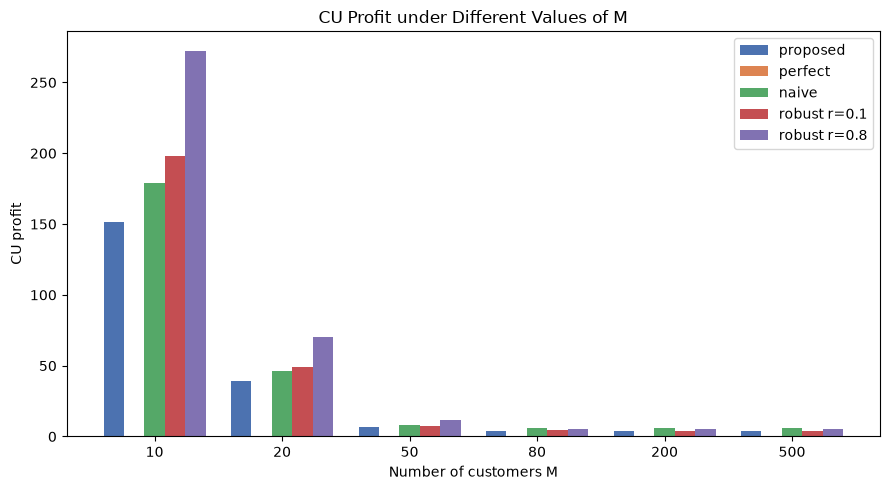

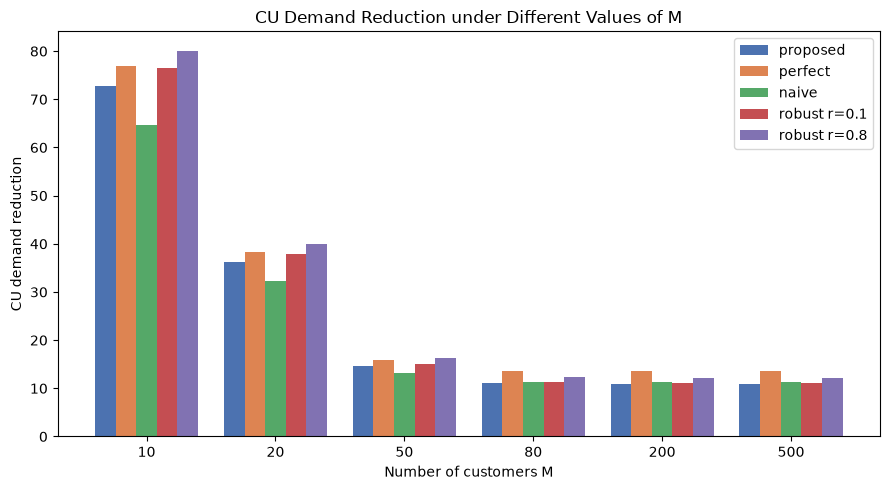

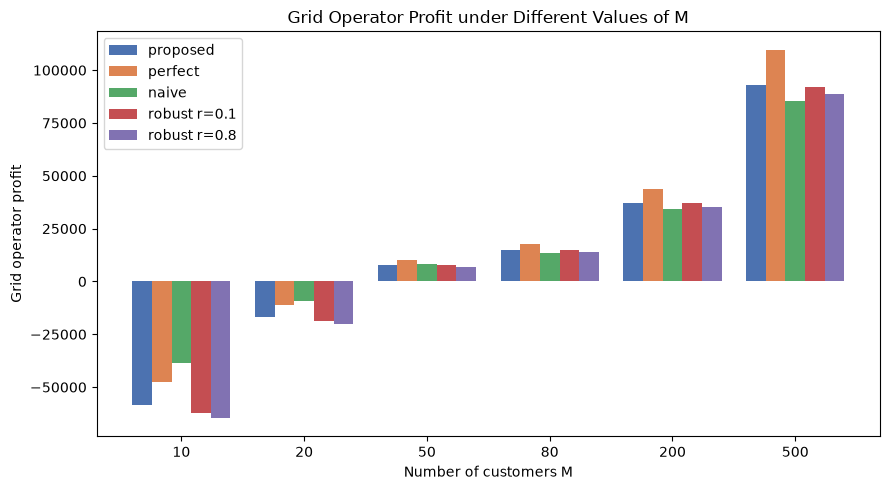

In [8]:
import matplotlib.pyplot as plt

M_VALUES = [10, 20, 50,80, 200, 500]
SCHEME_NAMES = ["proposed", "perfect", "naive", "robust r=0.1", "robust r=0.8"]
SCHEME_COLORS = {
    "proposed": "#4C72B0",
    "perfect": "#DD8452",
    "naive": "#55A868",
    "robust r=0.1": "#C44E52",
    "robust r=0.8": "#8172B2",
}

m_sweep_results = {m_val: {} for m_val in M_VALUES}

for m_val in M_VALUES:
    m_scenario = build_load_scenario(
        M=m_val,
        T=T,
        N=N,
        folder=Path(DATASET_DIR_NAME),
        price_scale=2.0,
        dreq_low=100.0,
        dreq_high=200.0,
        seed=42,
    )
    m_c_mat = build_cost_matrix(np.arange(N))
    T_h = m_scenario.T

    # --- Proposed ---
    m_proposed = solve_proposed_contract(
        M=m_scenario.M, T=m_scenario.T, N=m_scenario.N,
        Krt=m_scenario.Krt, Ks=m_scenario.Ks, Dreq=m_scenario.Dreq,
        pi=m_scenario.pi, alpha=m_scenario.alpha, beta=m_scenario.beta,
        f=f, verbose=0,
    )
    m_proposed_check = compute_contract_utilities(m_proposed.D, m_scenario.alpha, m_scenario.beta)
    m_sweep_results[m_val]["proposed"] = {
        "cu_profit": float(np.sum(m_proposed_check.truthful_total) / T_h),
        "cu_reduction": float(np.sum(m_proposed.D) / T_h),
        "operator_profit": float(m_proposed.objective),
    }

    # --- Perfect information (discriminatory) ---
    m_perfect = solve_perfect_information_contract(
        M=m_scenario.M, T=m_scenario.T, N=m_scenario.N,
        Krt=m_scenario.Krt, Ks=m_scenario.Ks, Dreq=m_scenario.Dreq,
        pi=m_scenario.pi, alpha=m_scenario.alpha, beta=m_scenario.beta,
        f=f, verbose=0,
    )
    m_perfect_utility = compute_discriminatory_utilities(m_perfect.D, m_scenario.alpha, m_scenario.beta)
    m_perfect_truthful_avg = np.diag(np.sum(m_perfect_utility, axis=2)) / T_h
    m_sweep_results[m_val]["perfect"] = {
        "cu_profit": float(np.sum(m_perfect_truthful_avg)),
        "cu_reduction": float(np.sum(m_perfect.D) / T_h),
        "operator_profit": float(m_perfect.objective),
    }

    # --- Naive ---
    m_naive = solve_naive_from_perfect(
        M=m_scenario.M, pi=m_scenario.pi, alpha=m_scenario.alpha, beta=m_scenario.beta,
        perfect_D=m_perfect.D,
    )
    m_naive_avg = np.sum(m_naive.utility, axis=1) / T_h
    m_sweep_results[m_val]["naive"] = {
        "cu_profit": float(np.sum(m_naive_avg)),
        "cu_reduction": float(np.sum(m_naive.D) / T_h),
        "operator_profit": float(m_naive.objective),
    }

    # --- Robust r=0.1 and r=0.8 ---
    for radius in robust_radii:
        m_sol = solve_robust_contract_convex(
            M=m_scenario.M, T=m_scenario.T, N=m_scenario.N,
            Krt=m_scenario.Krt, Ks=m_scenario.Ks, Dreq=m_scenario.Dreq,
            pi=m_scenario.pi, alpha=m_scenario.alpha, beta=m_scenario.beta,
            fhat=f, r=radius, c_mat=m_c_mat, verbose=False,
        )
        scheme_key = f"robust r={radius}"
        if m_sol.D is not None:
            m_check = compute_contract_utilities(m_sol.D, m_scenario.alpha, m_scenario.beta)
            m_sweep_results[m_val][scheme_key] = {
                "cu_profit": float(np.sum(m_check.truthful_total) / T_h),
                "cu_reduction": float(np.sum(m_sol.D) / T_h),
                "operator_profit": float(m_sol.objective),
            }
        else:
            m_sweep_results[m_val][scheme_key] = {
                "cu_profit": np.nan,
                "cu_reduction": np.nan,
                "operator_profit": np.nan,
            }

    profit_summary = ", ".join(
        f"{s}={m_sweep_results[m_val][s]['operator_profit']:.3f}" for s in SCHEME_NAMES
    )
    print(f"M={m_val} done: {profit_summary}")


def grouped_bar_chart(metric_key, ylabel, title, save_name):
    n_schemes = len(SCHEME_NAMES)
    x = np.arange(len(M_VALUES))
    width = 0.8 / n_schemes

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, scheme in enumerate(SCHEME_NAMES):
        values = [m_sweep_results[m][scheme][metric_key] for m in M_VALUES]
        offset = (i - (n_schemes - 1) / 2) * width
        ax.bar(x + offset, values, width, label=scheme, color=SCHEME_COLORS[scheme])

    ax.set_xticks(x)
    ax.set_xticklabels([str(m) for m in M_VALUES])
    ax.set_xlabel("Number of customers M")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / save_name, dpi=FIGURE_DPI)
    plt.show()


grouped_bar_chart(
    "cu_profit", "CU profit",
    "CU Profit under Different Values of M",
    "m_sweep_cu_profit_all_schemes.pdf",
)

grouped_bar_chart(
    "cu_reduction", "CU demand reduction",
    "CU Demand Reduction under Different Values of M",
    "m_sweep_cu_demand_reduction_all_schemes.pdf",
)

grouped_bar_chart(
    "operator_profit", "Grid operator profit",
    "Grid Operator Profit under Different Values of M",
    "m_sweep_operator_profit_all_schemes.pdf",
)


## Optional OT Distance Check

Use this cell when you want to measure how far an alternate empirical distribution is from the reference distribution.


In [9]:
from mechanism_design.transport import wasserstein_distance_discrete

fhat = np.ones(N, dtype=float) / N
distance, coupling = wasserstein_distance_discrete(f, fhat, C=c_mat)
print("Wasserstein distance from f to uniform fhat:", distance)
print("Optimal coupling:")
print(np.round(coupling, 4))


Wasserstein distance from f to uniform fhat: 0.49999999999999983
Optimal coupling:
[[0.2  0.1  0.   0.   0.  ]
 [0.   0.1  0.15 0.   0.  ]
 [0.   0.   0.05 0.05 0.1 ]
 [0.   0.   0.   0.15 0.  ]
 [0.   0.   0.   0.   0.1 ]]
